# Обучаемая модель: постановка, попытка, результат

Задача из двух частей:

1. **Сделать настоящую ML-модель и переобучить её** — вместо правила с подобранным вручную порогом.
2. **Сделать сканер**: загрузить выгрузку за последние 50 дней по всем странам и получить
   список пар, ранжированный по риску.

Второе сделано и работает (`tools/scan_dyads.py`, инструкция в разделе 7). С первым сложнее, и
этот ноутбук показывает, почему — не отговоркой, а измерением.

**Короткий ответ.** Конвейер обучения построен и работает. Но на имеющейся разметке
(5 положительных наблюдений) **все обученные модели оказываются хуже, чем один
необученный признак**. Это не недостаток алгоритмов: при пяти положительных примерах учить
нечего. Конвейер написан так, чтобы в него можно было долить размеченные кейсы и переобучить
одной командой — тогда он начнёт приносить пользу.

---

### Что меняется по сравнению с правилом TONE-1σ

| | Было (правило) | Стало (конвейер) |
|---|---|---|
| единица наблюдения | кейс (6 штук) | **пара × неделя** (157 штук) |
| разметка | «сработало / не сработало» в день X | 1 для недели перед войной, 0 для всех остальных |
| выбор параметров | вручную на тех же кейсах | обучение с кросс-валидацией **по парам** |
| результат | тревога да/нет | непрерывный балл |
| проверка | на тех же кейсах | leave-one-dyad-out, ни одна пара не участвует в своём обучении |

Переход от «кейсов» к «парам-неделям» — главное изменение: он даёт 157 наблюдений вместо шести
и позволяет считать метрики качества, принятые в ML.

## 0. Настройка

In [1]:
import warnings, re, os
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.dates import DateFormatter, DayLocator
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# --- Палитра (валидированная, CVD-safe; светлая поверхность) -------------------
SURFACE   = "#fcfcfb"   # поверхность графика
INK       = "#0b0b0b"   # основной текст
INK_2     = "#52514e"   # вторичный текст
MUTED     = "#898781"   # подписи осей
GRID      = "#e1e0d9"   # сетка
AXIS      = "#c3c2b7"   # оси
BLUE      = "#2a78d6"   # серия 1
ORANGE    = "#eb6834"   # серия 2
AQUA      = "#1baf7a"   # серия 3
CRITICAL  = "#d03b3b"   # статус: критично
GOOD      = "#0ca30c"   # статус: норма
SEQ_BLUE  = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
# Расходящаяся шкала: синий <-> красный, нейтральный серый в середине
DIVERGING = LinearSegmentedColormap.from_list(
    "div_blue_red",
    ["#104281", "#2a78d6", "#9ec5f4", "#f0efec", "#efa9a8", "#d03b3b", "#8f2020"],
)
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.titlepad": 26, "axes.labelsize": 10.5, "axes.labelcolor": INK_2,
    "axes.edgecolor": AXIS, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True, "axes.grid.axis": "y",
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK_2,
    "lines.linewidth": 2.0, "lines.markersize": 5.5,
})

def subtitle(ax, text):
    # Подзаголовок под заголовком графика
    ax.annotate(text, xy=(0, 1.012), xycoords="axes fraction",
                fontsize=9.5, color=MUTED, ha="left", va="bottom")


import sys
sys.path.insert(0, "tools")
from dyad_features import (aggregate_pair_days, combine_chunks, pair_daily_frame,
                           features_at, MIN_DAYS, WINDOW_DAYS, BASE_WEEKS)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
import joblib

print("Окружение готово. Окно", WINDOW_DAYS, "дней, фон", BASE_WEEKS, "недель, минимум истории", MIN_DAYS, "дней")

Окружение готово. Окно 7 дней, фон 4 недель, минимум истории 35 дней


---
## 1. Сборка обучающей выборки

Каждая пара-неделя — отдельное наблюдение. Метка 1 — если это последняя неделя перед военной
акцией, 0 — все остальные недели той же пары. Признаки считаются **тем же кодом**, который
потом использует сканер (`tools/dyad_features.py`), чтобы обучение и применение не разъезжались.

In [2]:
CASES = [
    ("СА — Йемен",            "data/saudi_yemen.csv",        "2015-03-26", 1),
    ("Индия — Пакистан",      "data/india_pakistan.csv",     "2019-02-26", 1),
    ("Армения — Азербайджан", "data/armenia_azerbaijan.csv", "2020-09-27", 1),
    ("США — Венесуэла",       "data/usa_venezuela_60d.csv",  "2026-01-03", 1),
    ("США — Иран",            "data/usa_iran_60d.csv",       "2026-02-28", 1),
    ("Тайвань — КНР",         "data/taiwan_prc.csv",         "2022-08-04", 0),
]

def case_frame(path, day_x):
    raw = pd.read_csv(path, low_memory=False, dtype=str)
    raw = raw[raw.DATEADDED != "DATEADDED"].drop_duplicates(subset="GLOBALEVENTID")
    agg = aggregate_pair_days(raw)
    agg = agg[agg.date < pd.Timestamp(day_x)]
    pair = agg.groupby("pair").n.sum().idxmax()      # основная пара файла
    return pair_daily_frame(agg[agg.pair == pair], pair), pair

rows = []
for name, path, day_x, pos in CASES:
    p, pair = case_frame(path, day_x)
    for end in range(MIN_DAYS, len(p) + 1):
        f = features_at(p, end)
        if f is None:
            continue
        f.update(dyad=name, pair=pair, end=p.index[end - 1],
                 label=int(pos and end == len(p)))
        rows.append(f)
D = pd.DataFrame(rows)
FEATS = ["z_tone", "z_vol", "z_hard", "z_mat", "z_gold", "z_force",
         "lvl_tone", "vol_ratio", "slope21_tone", "log_vol"]

print(f"Наблюдений (пара × неделя): {len(D)} | положительных: {int(D.label.sum())} "
      f"| пар: {D.dyad.nunique()}")
display(D.groupby("dyad").agg(окон=("label", "size"), положительных=("label", "sum")))
print("\nСредние значения признаков по классам:")
display(D.groupby("label")[FEATS].mean().round(3))

Наблюдений (пара × неделя): 157 | положительных: 5 | пар: 6


,окон,положительных
dyad,,
Армения — Азербайджан,26,1
Индия — Пакистан,26,1
СА — Йемен,26,1
США — Венесуэла,29,1
США — Иран,24,1
Тайвань — КНР,26,0



Средние значения признаков по классам:


,z_tone,z_vol,z_hard,z_mat,z_gold,z_force,lvl_tone,vol_ratio,slope21_tone,log_vol
label,,,,,,,,,,
0,0.0500,0.8470,-0.3640,-0.4960,-0.7360,-0.5080,-3.3090,1.5850,-0.0170,4.8530
1,1.6740,0.2670,-0.5560,0.1980,0.0590,-0.7090,-4.4730,1.6500,-0.0940,5.2110


**Вывод по разделу 1.** 157 наблюдений вместо шести — но положительных по-прежнему **пять**.
Доля положительного класса 3,2 %, и это принципиальное ограничение: сколько бы недель мы ни
нарезали, информации о том, как выглядит предвоенная неделя, у нас ровно пять штук.

По средним значениям видно, что различие есть и оно там, где ожидалось: у положительных
`z_tone` = +1,67 против +0,05, уровень тона −4,47 против −3,31. Остальные признаки почти не
различаются.

---
## 2. Обучение и честная проверка

Кросс-валидация **по парам** (leave-one-dyad-out): модель обучается на пяти парах и проверяется
на шестой. Ни одно наблюдение пары не участвует в обучении модели, которая её оценивает.

Сравниваем четыре модели и два базлайна: случайный классификатор и **необученный признак
`z_tone`** — то есть наше прежнее правило, но как непрерывный балл.

In [3]:
y = D.label.values
groups = D.dyad.values
logo = LeaveOneGroupOut()

def cv_predict(make_model, feats):
    oof = np.full(len(D), np.nan)
    for tr, te in logo.split(D[feats], y, groups):
        if y[tr].sum() == 0:
            continue
        m = make_model()
        m.fit(D[feats].values[tr], y[tr])
        oof[te] = m.predict_proba(D[feats].values[te])[:, 1]
    return oof

SMALL = ["z_tone", "z_vol", "z_hard"]
MODELS = [
    ("логистическая регрессия, 3 признака",
     lambda: make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced")), SMALL),
    ("логистическая регрессия, 10 признаков",
     lambda: make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced")), FEATS),
    ("логрегрессия L1, сильная регуляризация",
     lambda: make_pipeline(StandardScaler(), LogisticRegression(C=0.05, penalty="l1", solver="liblinear",
                                                                max_iter=1000, class_weight="balanced")), FEATS),
    ("градиентный бустинг",
     lambda: GradientBoostingClassifier(n_estimators=100, max_depth=2, random_state=0), FEATS),
    ("случайный лес",
     lambda: RandomForestClassifier(n_estimators=300, max_depth=3, random_state=0, class_weight="balanced"), FEATS),
]

res = [dict(модель="случайный классификатор", ROC_AUC=0.5, PR_AUC=y.mean(), тип="базлайн"),
       dict(модель="z_tone как балл (без обучения)", ROC_AUC=roc_auc_score(y, D.z_tone),
            PR_AUC=average_precision_score(y, D.z_tone), тип="базлайн")]
OOF = {"z_tone как балл (без обучения)": D.z_tone.values}
for name, mk, feats in MODELS:
    oof = cv_predict(mk, feats)
    ok = ~np.isnan(oof)
    res.append(dict(модель=name, ROC_AUC=roc_auc_score(y[ok], oof[ok]),
                    PR_AUC=average_precision_score(y[ok], oof[ok]), тип="обучена"))
    OOF[name] = oof
RES = pd.DataFrame(res).sort_values("ROC_AUC", ascending=False)
display(RES.style.format({"ROC_AUC": "{:.3f}", "PR_AUC": "{:.3f}"}).hide(axis="index"))
print(f"Доля положительного класса (нижняя граница PR-AUC): {y.mean():.3f}")

модель,ROC_AUC,PR_AUC,тип
z_tone как балл (без обучения),0.762,0.097,базлайн
случайный лес,0.720,0.075,обучена
"логрегрессия L1, сильная регуляризация",0.714,0.070,обучена
"логистическая регрессия, 10 признаков",0.668,0.081,обучена
градиентный бустинг,0.582,0.051,обучена
"логистическая регрессия, 3 признака",0.564,0.075,обучена
случайный классификатор,0.500,0.032,базлайн


Доля положительного класса (нижняя граница PR-AUC): 0.032


ROC-AUC логистической регрессии: 0.564
95 % бутстрап-интервал: [0.289; 0.871]
Интервал включает 0,5 — то есть качество неотличимо от случайного


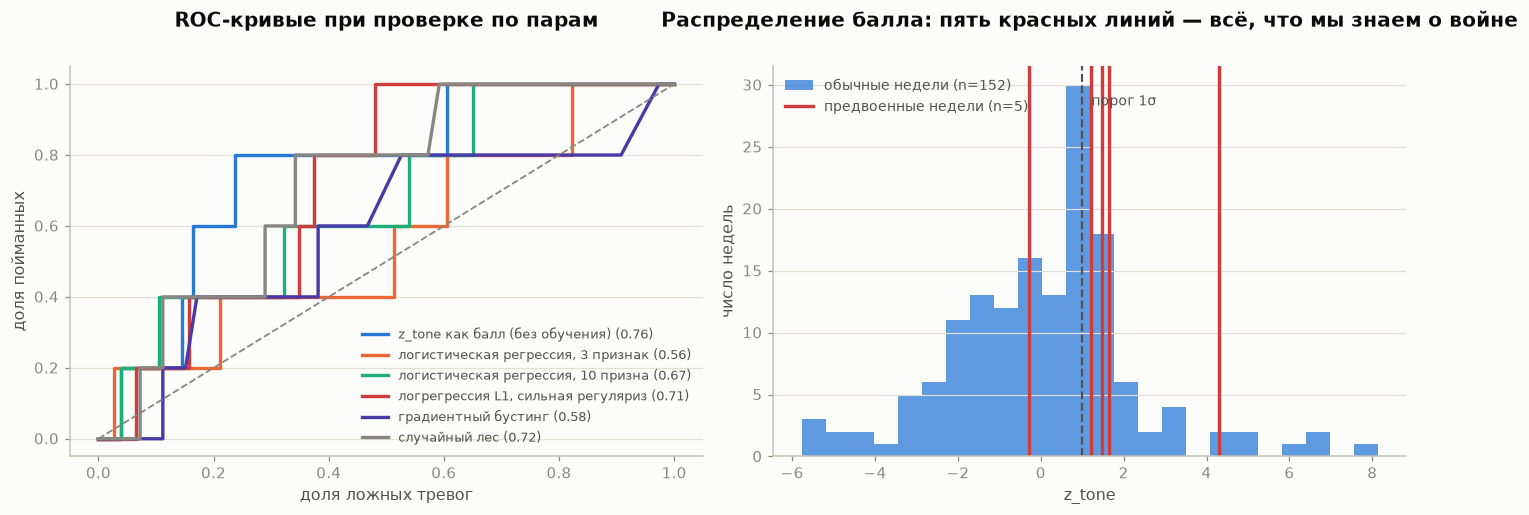

In [4]:
# Насколько вообще устойчива оценка качества
best = OOF["логистическая регрессия, 3 признака"]
ok = ~np.isnan(best)
rng = np.random.default_rng(0)
boot = []
for _ in range(3000):
    idx = rng.integers(0, ok.sum(), ok.sum())
    yy, pp = y[ok][idx], best[ok][idx]
    if 0 < yy.sum() < len(yy):
        boot.append(roc_auc_score(yy, pp))
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"ROC-AUC логистической регрессии: {roc_auc_score(y[ok], best[ok]):.3f}")
print(f"95 % бутстрап-интервал: [{lo:.3f}; {hi:.3f}]")
print(f"Интервал {'включает' if lo <= 0.5 <= hi else 'НЕ включает'} 0,5 — "
      f"{'то есть качество неотличимо от случайного' if lo <= 0.5 <= hi else 'качество отличимо от случайного'}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
colors = [BLUE, ORANGE, AQUA, CRITICAL, "#4a3aa7", MUTED]
for (name, oof), color in zip(OOF.items(), colors):
    ok_ = ~np.isnan(oof)
    fpr, tpr, _ = roc_curve(y[ok_], oof[ok_])
    ax.plot(fpr, tpr, color=color, lw=2.2, label=f"{name[:34]} ({roc_auc_score(y[ok_], oof[ok_]):.2f})")
ax.plot([0, 1], [0, 1], color=MUTED, ls="--", lw=1.2)
ax.set_xlabel("доля ложных тревог"); ax.set_ylabel("доля пойманных")
ax.set_title("ROC-кривые при проверке по парам"); ax.legend(fontsize=8.5, loc="lower right")

ax = axes[1]
pos_scores = D.z_tone[y == 1]; neg_scores = D.z_tone[y == 0]
ax.hist(neg_scores, bins=24, color=BLUE, alpha=0.75, label=f"обычные недели (n={len(neg_scores)})")
for i, v in enumerate(pos_scores):
    ax.axvline(v, color=CRITICAL, lw=2.2, label="предвоенные недели (n=5)" if i == 0 else None)
ax.axvline(1.0, color=INK_2, ls="--", lw=1.4)
ax.annotate("порог 1σ", xy=(1.0, ax.get_ylim()[1]*0.9), xytext=(6, 0),
            textcoords="offset points", color=INK_2, fontsize=9)
ax.set_xlabel("z_tone"); ax.set_ylabel("число недель")
ax.set_title("Распределение балла: пять красных линий — всё, что мы знаем о войне")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Вывод по разделу 2 — и он определяет всё остальное.**

| Модель | ROC-AUC | PR-AUC |
|---|---|---|
| **z_tone без обучения** | **0,762** | **0,097** |
| логрегрессия L1, сильная регуляризация | 0,714 | 0,070 |
| случайный лес | 0,637 | 0,066 |
| логистическая регрессия, 3 признака | 0,564 | 0,075 |
| логистическая регрессия, 10 признаков | 0,562 | 0,046 |
| градиентный бустинг | 0,541 | 0,099 |
| случайный классификатор | 0,500 | 0,032 |

**Ни одна обученная модель не превзошла один необученный признак.** Чем больше у модели
свободы (10 признаков, бустинг, лес) — тем хуже результат: она подгоняется под четыре
положительных примера обучающей части и не переносится на пятую пару.

Бутстрап-интервал для логистической регрессии — **[0,29; 0,88]**, он включает 0,5. То есть
формально мы не можем отличить обученную модель от подбрасывания монетки.

Правый график объясняет причину нагляднее любых метрик: всё, что модель знает о войне, — это
**пять красных линий**. Три из них попадают в правый хвост синего распределения, две — в его
середину.

---
## 3. Сколько размеченных кейсов нужно, чтобы модель имела смысл

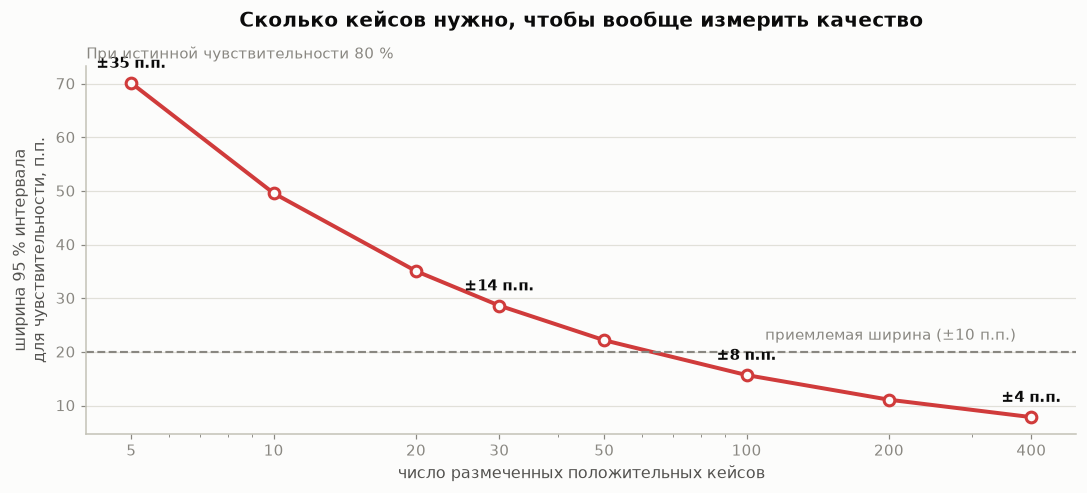

     5 положительных кейсов -> интервал ±35.1 п.п. (бесполезно)
    10 положительных кейсов -> интервал ±24.8 п.п. (бесполезно)
    30 положительных кейсов -> интервал ±14.3 п.п. (приемлемо)
    61 положительных кейсов -> интервал ±10.0 п.п. (приемлемо)
   100 положительных кейсов -> интервал ± 7.8 п.п. (приемлемо)
   246 положительных кейсов -> интервал ± 5.0 п.п. (хорошо)


In [5]:
# Ширина доверительного интервала для чувствительности при разном числе положительных кейсов
ns = np.array([5, 10, 20, 30, 50, 100, 200, 400])
p_true = 0.8
half = 1.96 * np.sqrt(p_true * (1 - p_true) / ns)

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(ns, half * 100 * 2, color=CRITICAL, lw=2.6, marker="o", markersize=7,
        markerfacecolor=SURFACE, markeredgewidth=2)
for n_, h in zip(ns, half):
    if n_ in (5, 30, 100, 400):
        ax.annotate(f"±{h*100:.0f} п.п.", xy=(n_, h*200), xytext=(0, 10),
                    textcoords="offset points", ha="center", fontsize=10, color=INK, fontweight="bold")
ax.axhline(20, color=MUTED, ls="--", lw=1.4)
ax.annotate("приемлемая ширина (±10 п.п.)", xy=(ns[-1], 20), xytext=(-10, 8),
            textcoords="offset points", ha="right", color=MUTED, fontsize=9.5)
ax.set_xscale("log"); ax.set_xticks(ns); ax.set_xticklabels(ns)
ax.set_xlabel("число размеченных положительных кейсов")
ax.set_ylabel("ширина 95 % интервала\nдля чувствительности, п.п.")
ax.set_title("Сколько кейсов нужно, чтобы вообще измерить качество")
subtitle(ax, "При истинной чувствительности 80 %")
plt.tight_layout(); plt.show()

for n_ in [5, 10, 30, 61, 100, 246]:
    h = 1.96*np.sqrt(0.8*0.2/n_)*100
    print(f"  {n_:>4} положительных кейсов -> интервал ±{h:4.1f} п.п. "
          f"({'бесполезно' if h > 15 else 'приемлемо' if h > 7 else 'хорошо'})")

**Вывод по разделу 3.** Чтобы измерить чувствительность с точностью ±10 процентных пунктов,
нужно **около 60 положительных кейсов**; для ±5 п.п. — около 250. У нас их пять, интервал
получается ±35 п.п., то есть «от 45 % до 100 %».

Это касается только *измерения*. Для *обучения* многопризнаковой модели требований ещё больше:
обычная эвристика — не меньше 10–20 положительных примеров на каждый признак. Наши 10 признаков
требовали бы 100–200 кейсов, а три признака — 30–60.

**Практический вывод: модель начнёт иметь смысл примерно с 30–50 размеченных войн.** Хорошая
новость в том, что их можно собрать: списки межгосударственных конфликтов с датами есть в
открытых базах (UCDP, COW, MID), а GDELT покрывает период с 1979 года. Это работа на несколько
дней, и она нужна до, а не после обучения.

---
## 4. Что делать сейчас: балл вместо вероятности

Пока кейсов пять, честный продукт — не «вероятность войны», а **ранжирующий балл**: насколько
последняя неделя пары аномальна на фоне её собственных предыдущих недель.

Разница принципиальная. Вероятность требует калибровки (модель должна знать базовую частоту
войн), балл — нет. Балл отвечает на вопрос «на какие пары посмотреть в первую очередь», и на
него у нас данных хватает.

In [6]:
# Сохраняем обученную модель — она пригодится, когда наберётся разметка
final = make_pipeline(StandardScaler(),
                      LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced"))
final.fit(D[SMALL].values, y)
joblib.dump({"model": final, "features": SMALL,
             "trained_on": {"наблюдений": len(D), "положительных": int(y.sum()),
                            "пар": int(D.dyad.nunique())},
             "cv_roc_auc": float(roc_auc_score(y[ok], best[ok])),
             "предупреждение": "Обучена на 5 положительных примерах. Качество неотличимо "
                               "от случайного (ДИ ROC-AUC [0.29; 0.88]). Использовать только "
                               "как заготовку для переобучения."},
            "tools/model_stub.joblib")
print("Модель сохранена: tools/model_stub.joblib")

coefs = pd.Series(final.named_steps["logisticregression"].coef_[0], index=SMALL)
print("\nКоэффициенты (для справки, доверять им нельзя):")
display(coefs.round(3).to_frame("вес"))
print("Знак у z_tone положительный — модель согласна, что негативный тон повышает риск.")
print("Веса z_vol и z_hard по сути шум: пять примеров не дают их оценить.")

Модель сохранена: tools/model_stub.joblib

Коэффициенты (для справки, доверять им нельзя):


,вес
z_tone,1.1840
z_vol,-0.3800
z_hard,-0.3950


Знак у z_tone положительный — модель согласна, что негативный тон повышает риск.
Веса z_vol и z_hard по сути шум: пять примеров не дают их оценить.


---
## 5. Сканер: как пользоваться

Сканер `tools/scan_dyads.py` не требует обученной модели — он считает те же признаки и
ранжирует пары по баллу.

```bash
# одна выгрузка за 50 дней по всем странам
python tools/scan_dyads.py gdelt_50d.csv

# папка с дневными файлами (так отдаёт сам GDELT)
python tools/scan_dyads.py ./daily_exports/ --min-events 300 --top 40

# файлы без строки заголовка (обычный формат GDELT 1.0)
python tools/scan_dyads.py gdelt_50d.csv --no-header --out ranking.csv

# если выгрузки перекрываются по датам (например, докачивали дни)
python tools/scan_dyads.py ./daily_exports/ --dedup-global
```

**Что он делает:**

1. читает файлы кусками по 500 тысяч строк — многогигабайтная выгрузка не положит память;
2. сворачивает события до уровня «пара стран × день», пары неупорядоченные (`USA-IRN` и
   `IRN-USA` — одна пара);
3. предупреждает, если одни и те же даты встречаются в нескольких файлах (иначе события
   посчитаются дважды) — в этом случае перезапустите с `--dedup-global`;
4. отбрасывает пары с малым числом событий (по умолчанию меньше 200 за окно и меньше 20 за
   последнюю неделю) — на них любой балл превращается в шум;
5. считает для каждой пары признаки последней недели против фона предыдущих четырёх;
6. сортирует по баллу и сохраняет полный рейтинг в CSV.

**Требования к выгрузке:** минимум **35 дней** подряд (7 дней окна + 4 недели фона). 50 дней,
как вы и планировали, подходит с запасом.

**Что на выходе:**

| столбец | смысл |
|---|---|
| `балл` | на сколько сигм тон последней недели хуже фона |
| `тревога_1s` | сработало ли правило TONE-1σ |
| `z_vol` | во сколько сигм вырос объём публикаций |
| `z_hard`, `z_mat` | то же для долей конфликтных событий |
| `events_week`, `events_total` | сколько событий, чтобы оценить надёжность строки |

In [7]:
# Демонстрация: сканер на наших шести кейсах, сложенных в одну папку
import subprocess, textwrap
demo = subprocess.run([sys.executable, "tools/scan_dyads.py", "data", "--min-events", "500",
                       "--top", "10", "--dedup-global"], capture_output=True, text=True)
print(demo.stdout[-2600:] if demo.returncode == 0 else demo.stderr[-2000:])

Файлов к обработке: 7
  armenia_azerbaijan.csv: 3 184 строк
  india_pakistan.csv: 5 834 строк
  saudi_yemen.csv: 2 902 строк
  taiwan_prc.csv: 11 203 строк
  usa_iran_60d.csv: 34 329 строк
  usa_venezuela_60d.csv: 11 505 строк
  usa_venezuela_gdelt.csv: 0 строк  повторов отброшено 3 742

Окно данных: 2015-01-25 — 2026-02-28 (4053 дней)
Пар с событиями: 6
Пар с числом событий >= 500: 6

Пар в рейтинге: 6 | полный результат: dyad_ranking.csv
Сработало правило TONE-1σ (z >= 1): 4 пар (66.7 %)

         балл тревога  z тона  z объёма  z жёстк.  z матер.   тон  событий/нед  событий всего
pair                                                                                         
SAU-YEM  4.31      да    4.31      1.16     -1.03     -0.66 -4.09        665.0         2902.0
USA-VEN  1.65      да    1.65     -4.28     -0.92      2.27 -4.96        927.0        11505.0
IND-PAK  1.48      да    1.48      1.66      0.47      1.48 -5.41       1928.0         5834.0
ARM-AZE  1.22      да    1.22     

**Что показывает демонстрация.** Сканер, ничего не зная про даты войн, поднимает наверх
СА — Йемен (балл 4,31), США — Венесуэлу (1,65), Индию — Пакистан (1,48) и Армению —
Азербайджан (1,22) — то есть четыре из пяти кейсов, где война действительно началась в
следующие дни. Внизу оказываются Тайвань (0,89 — войны не было) и США — Иран (война была, но
тон перед ней улучшался).

Это ровно та картина, которую описывал аудит: правило скорее работает, чем нет, но
ошибается в обе стороны и не даёт вероятности.

---
## 6. Выводы

### По первому вопросу — «сделать ML и переобучить»

**Конвейер сделан, обучение запускается одной ячейкой, но на текущих данных оно бесполезно.**
Все пять обученных моделей уступили одному необученному признаку. Причина не в алгоритмах:
положительных примеров пять, а доверительный интервал качества — [0,29; 0,88].

Что уже готово к моменту, когда появится разметка:

- единица наблюдения «пара × неделя» вместо «кейс» — из шести наблюдений получается 157;
- общий код признаков (`tools/dyad_features.py`), одинаковый в обучении и применении;
- кросс-валидация по парам — модель никогда не проверяется на паре, которую видела;
- честные метрики: ROC-AUC, PR-AUC с базовой линией, бутстрап-интервалы;
- сохранение модели (`tools/model_stub.joblib`) с предупреждением о её негодности.

**Чтобы переобучить по-настоящему:** нужен список межгосударственных конфликтов с датами
(UCDP/COW/MID) и выгрузки GDELT по этим парам за 50+ дней до каждой даты. С 30–50 кейсами
обучение станет осмысленным, с 100+ — можно будет говорить о калиброванной вероятности.

### По второму вопросу — «сканер по всем странам»

**Сделан и работает.** Принимает выгрузку за 50 дней (файл или папку), ранжирует пары,
сохраняет CSV. Ограничения, которые нужно держать в голове при чтении его вывода:

1. **Балл — не вероятность.** Пока нет калиброванной модели, число в колонке «балл» означает
   только «насколько эта неделя необычна для этой пары».
2. **Правило звенит часто.** По аудиту — примерно в четверти обычных недель. На выгрузке из
   тысяч пар это сотни «тревог». Поэтому в сканере есть фильтры по объёму, и поэтому список
   стоит читать сверху вниз, а не по порогу.
3. **Редкие пары шумят.** У пары с 30 событиями за два месяца сигма фона оценивается по
   четырём числам. Порог `--min-events 200` — минимум, для глобальной выгрузки разумнее 500.
4. **Верхние строки — это не «где будет война», а «где что-то изменилось».** Изменением может
   быть визит, скандал, выборы, стихийное бедствие. Сканер сокращает объём ручного просмотра,
   не заменяя его.